In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import ResonanceFitData, PendulumsData, save_plot, bar_chart, bar_charts, plot_transient_decay

In [3]:
lengths = np.array([0.97, 0.99, 0.995, 1.0])
labels = ["97cm", "99cm", "99.5cm", "100cm"]

# tests
# lengths = np.array([1.01, 1.0, 0.995, 0.99])
# labels = ["101cm", "100cm", "99.5cm", "99cm"]

cols = ["mass A", "mass B", "mass C", "mass D"]
L_d = 1.0

In [4]:
increased_mass = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/increased-mass.csv").dropna()
)
doubled_mass = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/doubled-mass.csv").dropna()
)
short_dress = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/short-skirt.csv").dropna()
)
long_dress = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/long-skirt.csv").dropna()
)

In [5]:
# remove origin axis differences
increased_mass.preprocess_offsets()
doubled_mass.preprocess_offsets()
short_dress.preprocess_offsets()
long_dress.preprocess_offsets()

In [6]:
increased_mass_fit = ResonanceFitData(L_d, increased_mass)
doubled_mass_fit = ResonanceFitData(L_d, doubled_mass)
short_dress_fit = ResonanceFitData(L_d, short_dress)
long_dress_fit = ResonanceFitData(L_d, long_dress)

In [7]:
increased_mass_fit.fit_single_pendulums()
doubled_mass_fit.fit_single_pendulums()
short_dress_fit.fit_single_pendulums()
long_dress_fit.fit_single_pendulums()

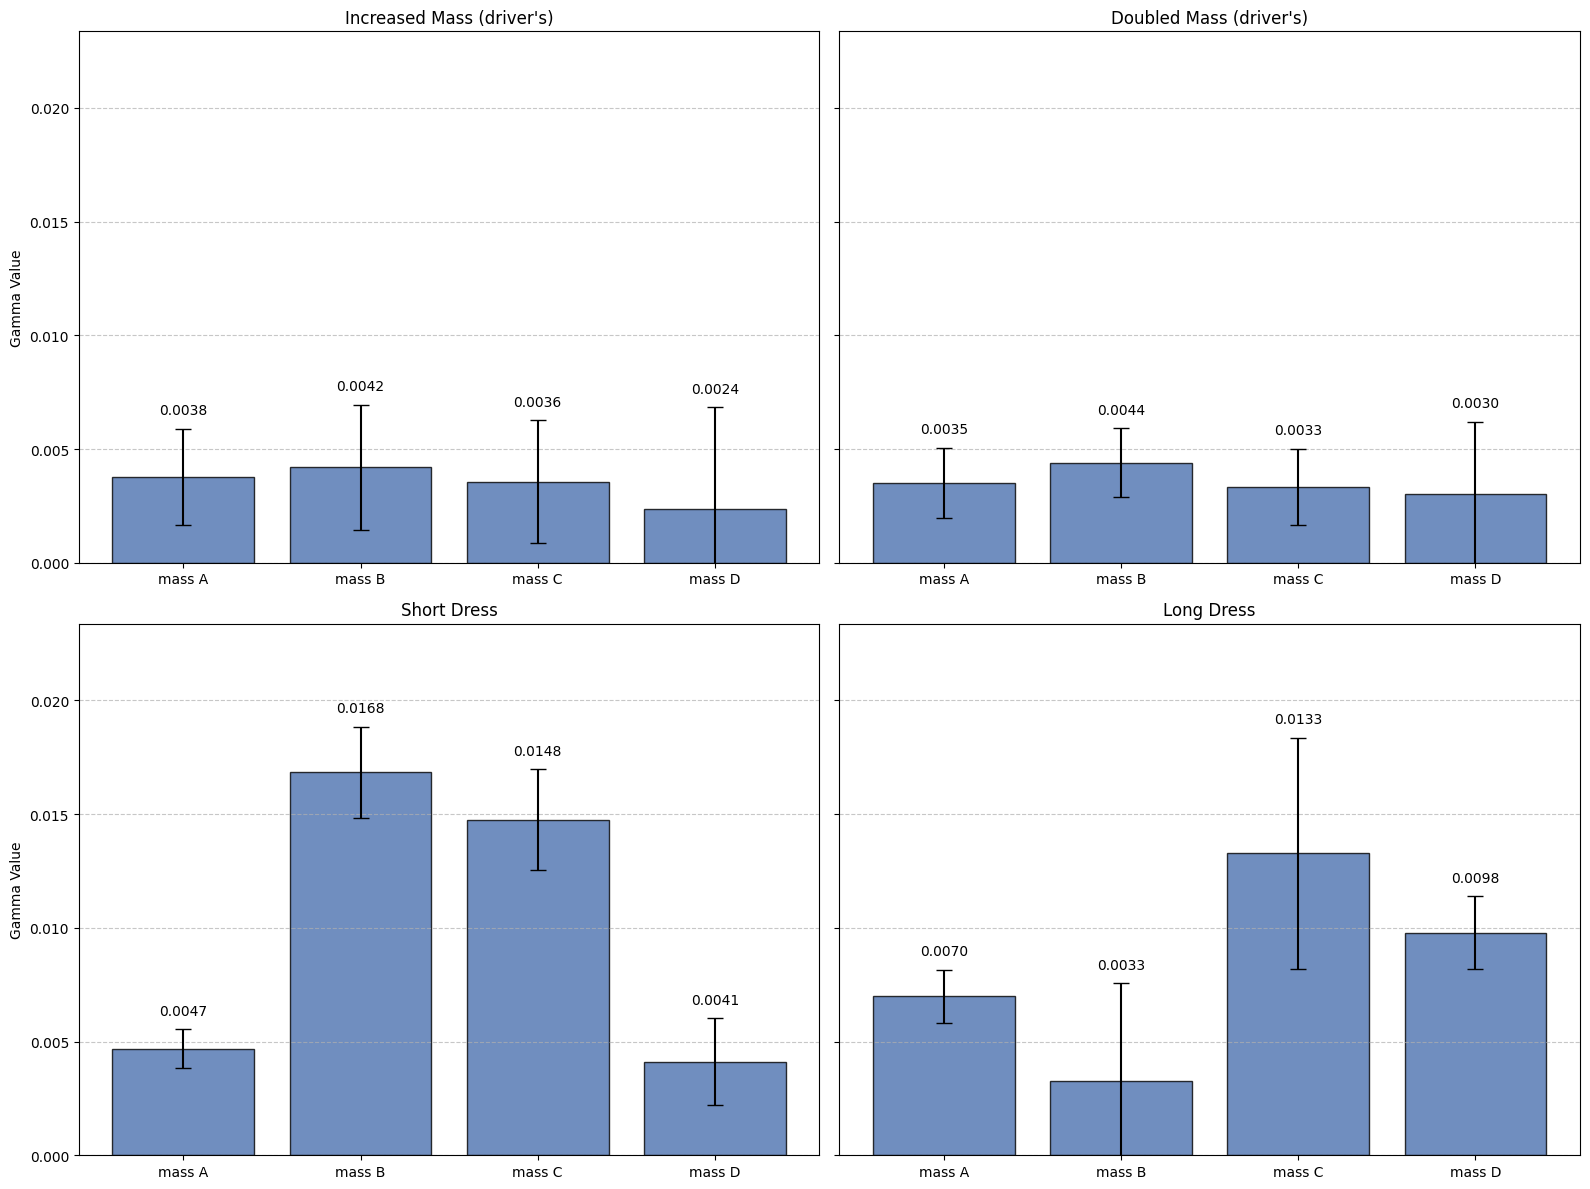

In [8]:
bar_charts(
    [
        increased_mass_fit.get_data_to_plot(),
        doubled_mass_fit.get_data_to_plot(),
        short_dress_fit.get_data_to_plot(),
        long_dress_fit.get_data_to_plot()
    ],
    ["Increased Mass (driver's)", "Doubled Mass (driver's)", "Short Dress", "Long Dress"]
)

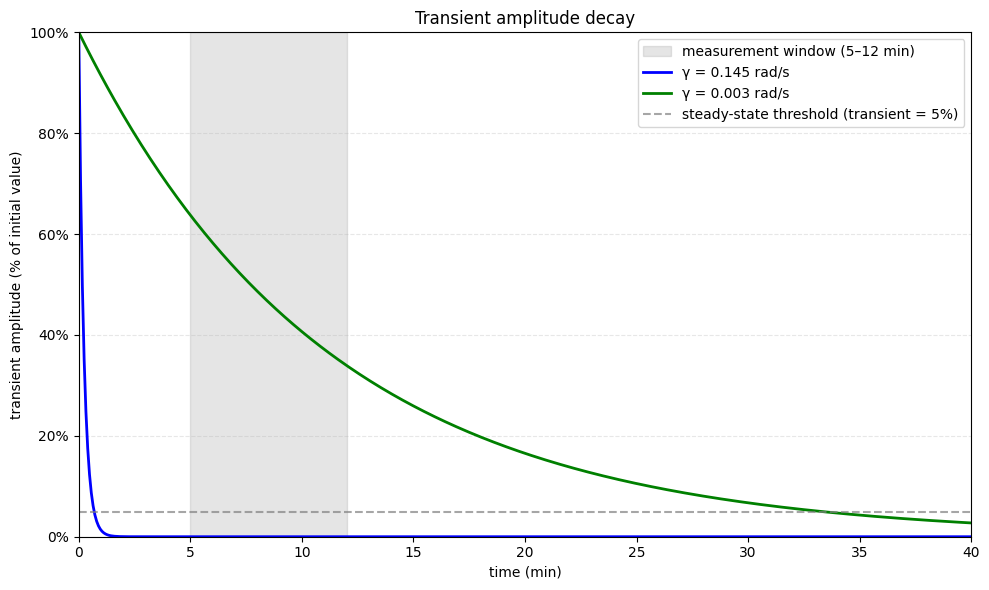

In [9]:
plot_transient_decay([0.145, 0.003], (0, 40), (5, 12), round_digits=4)
plt.show()